In [1]:
import matplotlib.pyplot as plt
import numpy as np

def draw_neural_network(ax, layer_sizes):
    n_layers = len(layer_sizes)

    # RIGHT → LEFT
    x_positions = np.linspace(1, 0, n_layers)

    node_positions = {}

    # Draw nodes
    for layer_idx, (layer_size, x) in enumerate(zip(layer_sizes, x_positions)):
        y_positions = np.linspace(0.9, 0.1, layer_size)

        for i, y in enumerate(y_positions):
            node_positions[(layer_idx, i)] = (x, y)

            if layer_idx == 0:
                color = 'lightcoral'
                label = f'$x_{i+1}$'
            elif layer_idx == n_layers - 1:
                color = 'lightblue'
                label = f'$y_{i+1}$'
            else:
                color = 'lightgreen'
                label = f'$h_{{{layer_idx},{i+1}}}$'

            ax.scatter(x, y, s=800, color=color, edgecolors='black', zorder=3)
            ax.text(x, y, label, ha='center', va='center', fontsize=10, weight='bold')

    # Draw edges
    for layer_idx in range(n_layers - 1):
        for i in range(layer_sizes[layer_idx]):
            for j in range(layer_sizes[layer_idx + 1]):
                x1, y1 = node_positions[(layer_idx, i)]
                x2, y2 = node_positions[(layer_idx + 1, j)]

                ax.plot([x1, x2], [y1, y2],
                        color='gray', alpha=0.3, linewidth=1)

    # Layer titles (top)
    for layer_idx, x in enumerate(x_positions):
        if layer_idx == 0:
            title = "Input (X)"
        elif layer_idx == n_layers - 1:
            title = "Output"
        else:
            title = f"Hidden Layer {layer_idx}"  # matrix interpretation

        ax.text(x, 1.05, title, ha='center', fontsize=12, weight='bold')

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1.1)

Given Parametrs:

In [2]:
x = [1.0, -2.0, 3.0]

In [3]:
W1 = [
    [0.2, - 0.5, 1.0],
    [1.5, 0.3, -0.8],
     [-1.0, 0.7, 0.2],
    [0.1, -0.2, 0.3]
]

In [4]:
b1 = [0.5, - 0.1, 0.0, 0.2]

In [5]:
W2 = [
    [0.3, - 1.2, 0.5, 0.7],
    [-0.6, 0.8, -0.3, 0.9]
]

In [6]:
b2 = [0.0, 0.1]

In [7]:
W3 = [1.0, -1.5]

In [8]:
b3 = [0.2]

In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


Task 0

In [10]:
torch.manual_seed(0)


In [11]:
sigma_l_minus_1 = torch.tensor(x)

In [12]:
# Weights (3 x 4)
W_1 = torch.tensor(W1)


In [13]:
#bias 4 x 1
b_1 = torch.tensor(b1)

In [14]:
Wx = W_1 @ sigma_l_minus_1

In [15]:
h1  = Wx + b_1

In [16]:
Wx

tensor([ 4.2000, -1.5000, -1.8000,  1.4000])

In [17]:
h1

tensor([ 4.7000, -1.6000, -1.8000,  1.6000])

In [18]:
W_2 = torch.tensor(W2)

In [19]:
torch.relu(h1)

tensor([4.7000, 0.0000, 0.0000, 1.6000])

### Task 1

In [20]:
Wx2 = W_2 @ torch.relu(h1)

In [21]:
b_2 = torch.tensor(b2)

In [22]:
h2 = Wx2 + b_2

In [23]:
h2

tensor([ 2.5300, -1.2800])

In [38]:
torch.relu(h2)

tensor([2.5300, 0.0000])

### Task 2

In [24]:
W_3 = torch.tensor(W3)

In [25]:
Wx3 = W_3 @ torch.relu(h2)

In [26]:
b_3 = torch.tensor(b3)

In [27]:
h3 = Wx3 + b_3

In [45]:
h3

tensor([[ 2.7300,  1.1650, -0.7590]], grad_fn=<AddmmBackward0>)

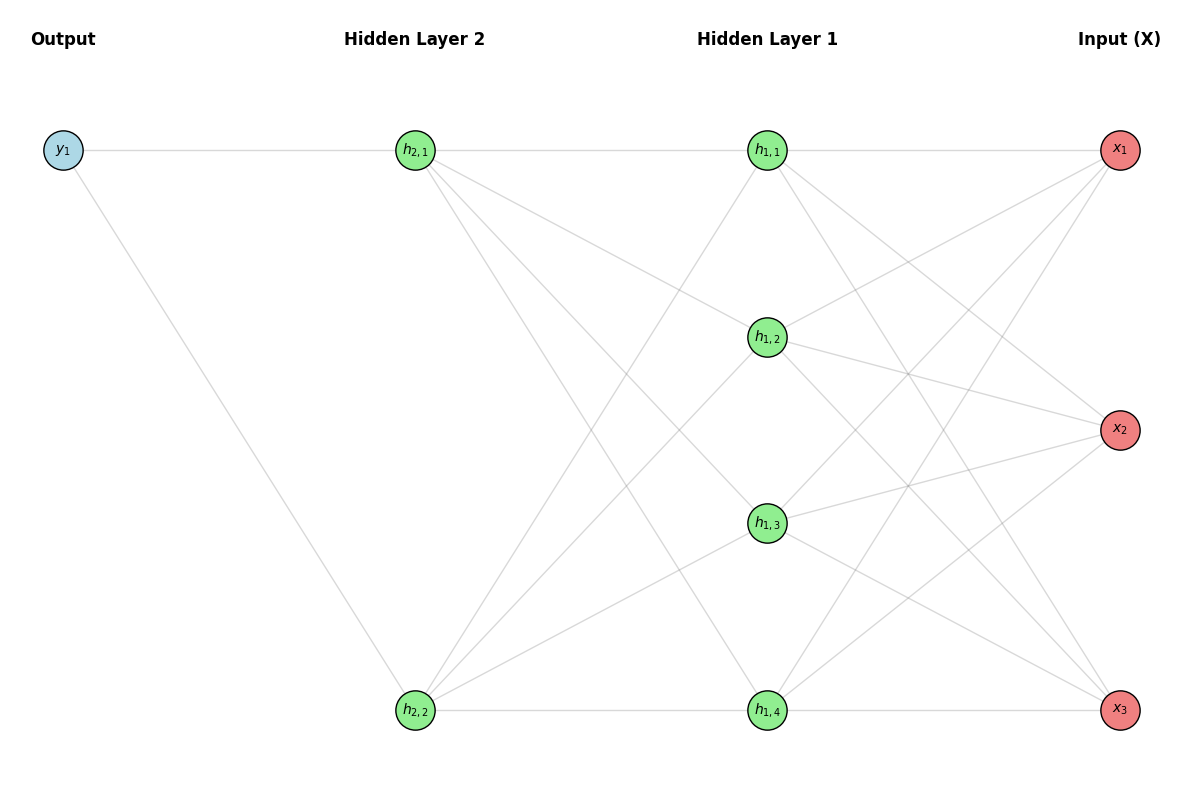

In [30]:
layer_sizes = [3, 4, 2, 1]
fig, ax = plt.subplots(figsize=(15, 10))
draw_neural_network(ax, layer_sizes)
plt.axis('off')
plt.show()

### Task 3

In [31]:
import torch.nn as nn

In [32]:
model = nn.Sequential(
    nn.Linear(3, 4),
    nn.ReLU(),
    nn.Linear(4, 2),
    nn.ReLU(),
    nn.Linear(2, 1)
)

In [34]:
with torch.no_grad():
    model[0].weight.copy_(torch.tensor([
        [0.2, -0.5, 1.0],
        [1.5, 0.3, -0.8],
        [-1.0, 0.7, 0.2],
        [0.1, -0.2, 0.3]
    ]))
    model[0].bias.copy_(torch.tensor([0.5, -0.1, 0.0, 0.2]))

    model[2].weight.copy_(torch.tensor([
        [0.3, -1.2, 0.5, 0.7],
        [-0.6, 0.8, -0.3, 0.9]
    ]))
    model[2].bias.copy_(torch.tensor([0.0, 0.1]))

    model[4].weight.copy_(torch.tensor([[1.0, -1.5]]))
    model[4].bias.copy_(torch.tensor([0.2]))

print(model(sigma_l_minus_1))

tensor([2.7300], grad_fn=<ViewBackward0>)


We have same output using torch.nn and manual calculations

## Task 4. Number of parameters in the neural network

To find the total number of trainable parameters, we count all weights and all biases in each layer.

The network has:
- 3 input features
- 4 neurons in the first hidden layer
- 2 neurons in the second hidden layer
- 1 output neuron

### First layer
Each of the 4 neurons in the first hidden layer receives 3 inputs, so the number of weights is:

\[
4 \times 3 = 12
\]

Each of these 4 neurons also has 1 bias, so the number of biases is:

\[
4
\]

Total parameters in the first layer:

\[
12 + 4 = 16
\]

### Second layer
Each of the 2 neurons in the second hidden layer receives 4 inputs, so the number of weights is:

\[
2 \times 4 = 8
\]

Each of these 2 neurons also has 1 bias, so the number of biases is:

\[
2
\]

Total parameters in the second layer:

\[
8 + 2 = 10
\]

### Output layer
The output neuron receives 2 inputs, so the number of weights is:

\[
1 \times 2 = 2
\]

The output neuron also has 1 bias, so the number of biases is:

\[
1
\]

Total parameters in the output layer:

\[
2 + 1 = 3
\]

### Final answer
Adding the parameters from all layers:

\[
16 + 10 + 3 = 29
\]

Therefore, the total number of trainable parameters in this neural network is:

29

In [35]:
y = model(sigma_l_minus_1)
print(y)

tensor([2.7300], grad_fn=<ViewBackward0>)


### Task 5

We have 3 class probability prediction neural network after modifying parameters. Sum of probabilities equals 1

## Task 5. Modified network with softmax output over 3 classes

In this task, the output layer is changed so that the network produces probabilities for 3 classes instead of one scalar value.

From the previous task, the output of the second hidden layer is

\[
\begin{bmatrix}
2.53 \\
0
\end{bmatrix}
\]

For the new output layer, I use the following weights:

\[
\begin{bmatrix}
1.0 & -1.5 \\
0.5 & 0.2 \\
-0.3 & 0.8
\end{bmatrix}
\]

and the following biases:

\[
\begin{bmatrix}
0.2 \\
-0.1 \\
0.0
\end{bmatrix}
\]

### Manual computation of the final layer

The first value before softmax is

\[
1.0(2.53) + (-1.5)(0) + 0.2 = 2.73
\]

The second value before softmax is

\[
0.5(2.53) + 0.2(0) - 0.1 = 1.165
\]

The third value before softmax is

\[
-0.3(2.53) + 0.8(0) + 0.0 = -0.759
\]

So the vector before softmax is

\[
\begin{bmatrix}
2.73 \\
1.165 \\
-0.759
\end{bmatrix}
\]

### Applying softmax

After applying softmax, the final output becomes

\[
\begin{bmatrix}
\frac{e^{2.73}}{e^{2.73}+e^{1.165}+e^{-0.759}} \\
\frac{e^{1.165}}{e^{2.73}+e^{1.165}+e^{-0.759}} \\
\frac{e^{-0.759}}{e^{2.73}+e^{1.165}+e^{-0.759}}
\end{bmatrix}
\]

Numerically, this is

\[
\begin{bmatrix}
0.8067 \\
0.1687 \\
0.0246
\end{bmatrix}
\]

### Verification

All entries are non-negative:

\[
0.8067 \ge 0, \qquad 0.1687 \ge 0, \qquad 0.0246 \ge 0
\]

Their sum is

\[
0.8067 + 0.1687 + 0.0246 = 1.0000
\]

Therefore, the final output is a valid probability vector.

### Number of parameters in the modified network

#### First layer
There are 4 neurons, and each neuron receives 3 inputs:

\[
4 \times 3 = 12
\]

There are also 4 biases:

\[
4
\]

So the first layer has

\[
12 + 4 = 16
\]

parameters.

#### Second layer
There are 2 neurons, and each neuron receives 4 inputs:

\[
2 \times 4 = 8
\]

There are also 2 biases:

\[
2
\]

So the second layer has

\[
8 + 2 = 10
\]

parameters.

#### Output layer
There are 3 output neurons, and each neuron receives 2 inputs:

\[
3 \times 2 = 6
\]

There are also 3 biases:

\[
3
\]

So the output layer has

\[
6 + 3 = 9
\]

parameters.

### Total number of parameters

\[
16 + 10 + 9 = 35
\]

So the modified network has

\[
\boxed{35}
\]

trainable parameters.

### Comparison with PyTorch

The manually computed final output is

\[
\begin{bmatrix}
0.8067 \\
0.1687 \\
0.0246
\end{bmatrix}
\]

The PyTorch result gives the same values, so the manual computation and the PyTorch implementation match.

### Why softmax is appropriate for multi-class classification

Softmax is appropriate for multi-class classification because it converts the final output into probabilities for each class. Every value is non-negative, and all values sum to 1. This makes the output easy to interpret as the probability of belonging to each class.

In the earlier task, the network produced only one scalar value, which is suitable for regression or a raw score. In this task, the network must choose among 3 classes, so a probability distribution is needed. That is why softmax is the correct activation function for the final layer.

In [40]:
import torch
import torch.nn as nn

x = torch.tensor([[1.0, -2.0, 3.0]], dtype=torch.float32)

class ModifiedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 4)
        self.fc2 = nn.Linear(4, 2)
        self.fc3 = nn.Linear(2, 3)

    def forward(self, x):
        h1 = self.fc1(x)
        sigma1 = torch.relu(h1)

        h2 = self.fc2(sigma1)
        sigma2 = torch.relu(h2)

        h3 = self.fc3(sigma2)
        sigma3 = torch.softmax(h3, dim=1)

        return h1, sigma1, h2, sigma2, h3, sigma3

model = ModifiedNet()

with torch.no_grad():
    model.fc1.weight.copy_(torch.tensor([
        [0.2, -0.5, 1.0],
        [1.5, 0.3, -0.8],
        [-1.0, 0.7, 0.2],
        [0.1, -0.2, 0.3]
    ], dtype=torch.float32))
    model.fc1.bias.copy_(torch.tensor([0.5, -0.1, 0.0, 0.2], dtype=torch.float32))

    model.fc2.weight.copy_(torch.tensor([
        [0.3, -1.2, 0.5, 0.7],
        [-0.6, 0.8, -0.3, 0.9]
    ], dtype=torch.float32))
    model.fc2.bias.copy_(torch.tensor([0.0, 0.1], dtype=torch.float32))

    model.fc3.weight.copy_(torch.tensor([
        [1.0, -1.5],
        [0.5, 0.2],
        [-0.3, 0.8]
    ], dtype=torch.float32))
    model.fc3.bias.copy_(torch.tensor([0.2, -0.1, 0.0], dtype=torch.float32))

h1, sigma1, h2, sigma2, h3, sigma3 = model(x)

print("h1 =", h1)
print("sigma1 =", sigma1)
print("h2 =", h2)
print("sigma2 =", sigma2)
print("h3 =", h3)
print("sigma3 =", sigma3)
print("sum of probabilities =", sigma3.sum(dim=1))

print("Total number of parameters =", sum(p.numel() for p in model.parameters()))

h1 = tensor([[ 4.7000, -1.6000, -1.8000,  1.6000]], grad_fn=<AddmmBackward0>)
sigma1 = tensor([[4.7000, 0.0000, 0.0000, 1.6000]], grad_fn=<ReluBackward0>)
h2 = tensor([[ 2.5300, -1.2800]], grad_fn=<AddmmBackward0>)
sigma2 = tensor([[2.5300, 0.0000]], grad_fn=<ReluBackward0>)
h3 = tensor([[ 2.7300,  1.1650, -0.7590]], grad_fn=<AddmmBackward0>)
sigma3 = tensor([[0.8067, 0.1687, 0.0246]], grad_fn=<SoftmaxBackward0>)
sum of probabilities = tensor([1.0000], grad_fn=<SumBackward1>)
Total number of parameters = 35


In [44]:
import pytz
from datetime import datetime

datetime.now(pytz.timezone("America/Chicago")).strftime("%Y/%m/%d %H:%M")

'2026/03/30 13:13'